#### Matrix Operations
- Next we move to several important operations and topics useful for proper understanding in ML.
- We'll work on topics like transformations, applying matrices, determinants, eigenvalues and eigenvectors etc.

##### Affine Transformations
- Affine transformations are change in geometry of vectors which may adjust distances or angles, but preserves the **parallelism** between them.
- In other words, a transformation is simply like a function which takes a vector as input and returns another vector as the output; whilest the grid lines remain parallel and evenly spaced.
- Hence we can conclude that a matrix represents a specific transformation and multiplying a vector by that matrix shows its computational and geometrical meaning.
- Transformations can be simple scaling, flipping, rotation, shearing etc. All linear transformations are affine but not the opposite way.
- When 2 (or maybe more) transformations are applied one after the other, the overall transformation is called the **Composition** of those 2.
- **Span** of a set of vectors is the collection of all possible vectors that can be reached by a linear combination of that set of vectors.

In [58]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [59]:
def plot_vectors(vectors, colors):
    """
    Plot one or more vectors in a 2D plane, specifying a color for each. 

    Arguments
    ---------
    vectors: list of lists or of arrays
        Coordinates of the vectors to plot. For example, [[1, 3], [2, 2]] 
        contains two vectors to plot, [1, 3] and [2, 2].
    colors: list
        Colors of the vectors. For instance: ['red', 'blue'] will display the
        first vector in red and the second in blue.
        
    Example
    -------
    plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
    plt.xlim(-1, 4)
    plt.ylim(-1, 4)
    """
    plt.figure()
    plt.axvline(x=0, color='lightgray')
    plt.axhline(y=0, color='lightgray')

    for i in range(len(vectors)):
        x = np.concatenate([[0,0],vectors[i]])
        plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                   angles='xy', scale_units='xy', scale=1, color=colors[i],)

In [60]:
v1 = np.array([3,1])
v1

array([3, 1])

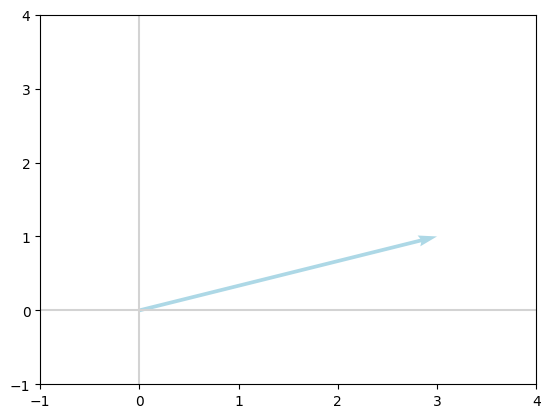

In [61]:
plot_vectors([v1], ['lightblue'])
plt.xlim(-1, 4)
_ = plt.ylim(-1, 4)

In [62]:
A = np.array([[-1, 4], [2, -2]])
A #can be called the transform or tha matrix which does it!

array([[-1,  4],
       [ 2, -2]])

In [63]:
Av = np.dot(A, v1)
Av #the result of the transformation done on v1

array([1, 4])

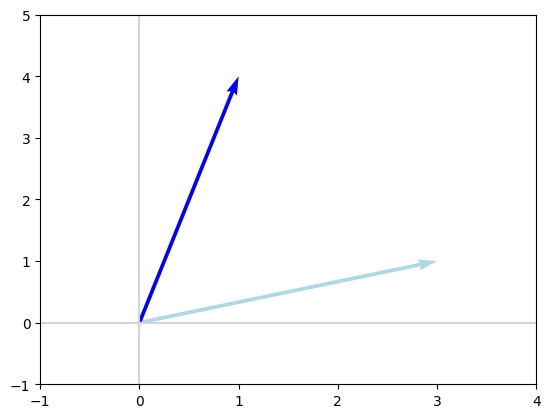

In [64]:
plot_vectors([v1, Av], ['lightblue', 'blue'])
plt.xlim(-1, 4)
_ = plt.ylim(-1, 5)

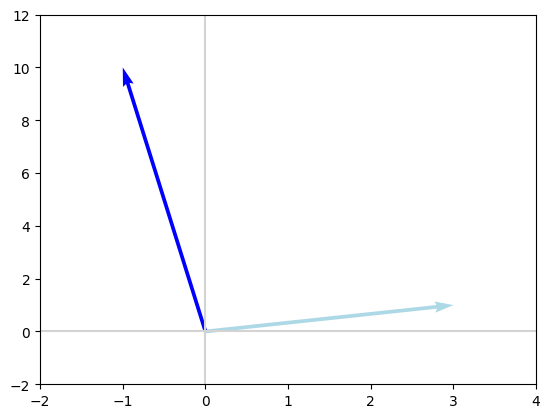

In [65]:
plot_vectors([v1, np.dot(v1, A)], ['lightblue', 'blue'])
plt.xlim(-2, 4)
_ = plt.ylim(-2, 12)
#here only difference was that the matrix was applied after v1. i.e. v1 x A and earlier we did A x v1. This shows that matrix multiplication is NOT always commutative!

##### The Determinant
- The Determinant is simply the **scaling factor** by which a transformation changes any area(covered by tensor)!
- The **magnitude** of determinant always tells how much scaling has been done.
- The **sign** of determinant tells that whether the orientation of space was changed while the transformation occured. i.e. its negative if the space was inverted!
- If the determinant is 0, it shows that such a transformation has occured that the space has been squished to a single point or a line, meaning that area has become zero!

In [66]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [67]:
np.linalg.det(X)

-2.0000000000000013

In [68]:
X2 = np.array([[4, 2], [2,1]])
np.linalg.det(X2)

0.0

In [69]:
X_pt = torch.tensor([[0,2], [-1.5, 1]])
torch.det(X_pt)

tensor(3.)